In [1]:
import s3fs
import pandas as pd
fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

## Examples

In [39]:
NAIVE_PATH = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/2026-03-16_google-gemma-3-27b-it_temp14_fewshot6_exhaustive.parquet"
RETEXT_PATH = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/retext-2026-06-05_gemma4-26b-moe_temp10_fewshot6_exhaustive.parquet"

df_naive = pd.read_parquet(NAIVE_PATH, filesystem=fs)
df_retext = pd.read_parquet(RETEXT_PATH, filesystem=fs)

In [53]:
sample = df_naive.sample(
n=10,
random_state=42
).reset_index(
    drop=True
).rename(
    columns={"label": "Naive Code2Text", "name": "Title"}
).merge(
    df_retext[["code", "label"]],
    on="code",
    how="left"
).rename(
    columns={"label": "Code2ReText", "code": "Code"}
).groupby(
    "Code"
).agg("first")

In [55]:
sample.to_csv("gen_examples.csv", sep=";", quoting=1)

## Wasserstein distance train

In [2]:
DATASET_METRICS_PATH = "s3://mateom/graal/compare_datasets.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "original_cleaned"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)
df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 55.90Y to 96.10H
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   count_A                  373 non-null    int64  
 1   count_B                  373 non-null    int64  
 2   count_C                  373 non-null    int64  
 3   wasserstein_distance_AC  373 non-null    float64
 4   wasserstein_distance_BC  373 non-null    float64
 5   wasserstein_distance_AB  373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 20.4+ KB


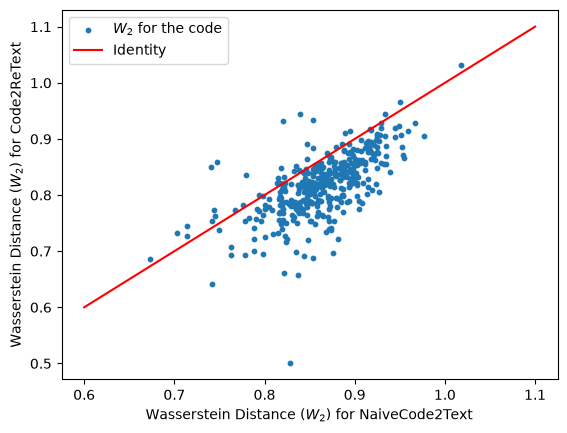

In [16]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(x=df_metrics["wasserstein_distance_AC"], y=df_metrics["wasserstein_distance_BC"], s=10, label="$W_2$ for the code")
plt.plot(np.linspace(0.6,1.1), np.linspace(0.6,1.1), c='red', label="Identity")
plt.xlabel("Wasserstein Distance ($W_2$) for NaiveCode2Text", fontsize=10)
plt.ylabel("Wasserstein Distance ($W_2$) for Code2ReText", fontsize=10)
plt.legend()
plt.show()

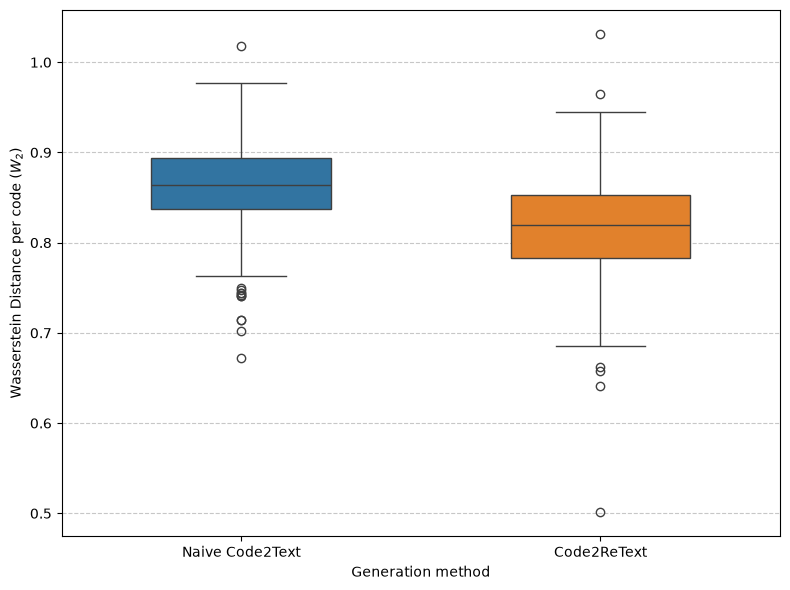

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].rename(
    columns={
        "wasserstein_distance_AC": "Naive Code2Text",
        "wasserstein_distance_BC": "Code2ReText",
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

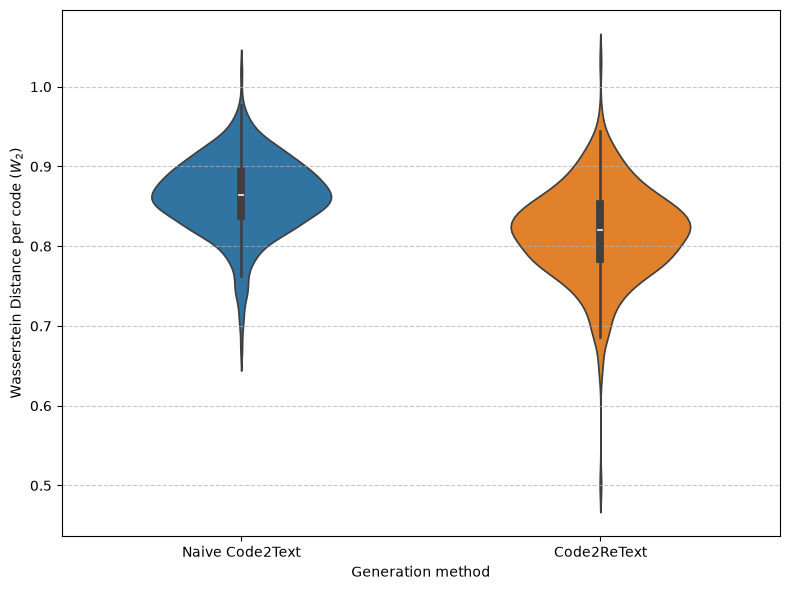

In [66]:
plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [67]:
# Extraction des séries en enlevant les potentielles valeurs manquantes (NaN)
# dues aux codes absents de certaines collections
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du test de Wilcoxon pour données appariées
stat, p_value = stats.wilcoxon(group_A, group_B)

print("--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---")
print(f"Statistique de test : {stat:.2f}")
print(f"p-value : {p_value:.5e}")

# Interprétation bayésienne/fréquentiste standard (seuil alpha à 5%)
alpha = 0.05
if p_value < alpha:
    print("\nConclusion : La différence est statistiquement significative (p < 0.05).")
    median_A = group_A.median()
    median_B = group_B.median()
    if median_B < median_A:
        print(f"Code2ReText (Médiane: {median_B:.4f}) est significativement plus proche de l'original C que Naive Code2Text (Médiane: {median_A:.4f}).")
    else:
        print(f"Naive Code2Text (Médiane: {median_A:.4f}) est significativement plus proche.")
else:
    print("\nConclusion : Pas de différence statistiquement significative détectée (p >= 0.05). Les deux méthodes ont des distributions de distances similaires.")

--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---
Statistique de test : 3653.00
p-value : 9.36633e-51

Conclusion : La différence est statistiquement significative (p < 0.05).
Code2ReText (Médiane: 0.8198) est significativement plus proche de l'original C que Naive Code2Text (Médiane: 0.8645).


In [68]:
from scipy import stats

# Nettoyage des données pour aligner parfaitement les codes
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du t-test apparié
t_stat, p_value = stats.ttest_rel(group_A, group_B)

print("--- Résultats du T-Test Apparié (Paired T-Test) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_value:.5e}")

alpha = 0.05
if p_value < alpha:
    mean_A = group_A.mean()
    mean_B = group_B.mean()
    print(f"\nConclusion : Différence statistiquement significative (p < 0.05).")
    if mean_B < mean_A:
        print(f"Code2ReText (Moyenne: {mean_B:.4f}) surpasse Naive Code2Text (Moyenne: {mean_A:.4f}) en se rapprochant de l'original.")
    else:
        print(f"Naive Code2Text (Moyenne: {mean_A:.4f}) est statistiquement plus proche.")
else:
    print("\nConclusion : Aucune différence statistiquement significative constatée.")

--- Résultats du T-Test Apparié (Paired T-Test) ---
Statistique t : 20.1415
p-value : 1.54425e-61

Conclusion : Différence statistiquement significative (p < 0.05).
Code2ReText (Moyenne: 0.8170) surpasse Naive Code2Text (Moyenne: 0.8629) en se rapprochant de l'original.


In [ ]:
import pingouin as pg

# Nettoyage et alignement des données
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

# Calcul du t-test bayésien apparié
# 'paired=True' active la comparaison intra-code
res = pg.ttest(
    df_clean["wasserstein_distance_AC"], 
    df_clean["wasserstein_distance_BC"], 
    paired=True
)

# Extraction des indicateurs clés
bf10 = res['BF10'].astype(float).values[0]
d_cohen = res['cohen_d'].values[0]
p_val = res['p_val'].values[0]  # Fourni aussi par pingouin pour comparaison

print("--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---")
print(f"Facteur de Bayes (BF10) : {bf10:.4e}")
print(f"Taille de l'effet (d de Cohen) : {d_cohen:.4f}")

print("\n--- INTERPRÉTATION BAYÉSIENNE ---")
# Échelle d'interprétation de Jeffreys pour le Facteur de Bayes
if bf10 > 100:
    print("Preuve extrême en faveur d'une différence entre les deux méthodes.")
elif bf10 > 30:
    print("Preuve très forte en faveur d'une différence.")
elif bf10 > 10:
    print("Preuve forte en faveur d'une différence.")
elif bf10 > 3:
    print("Preuve modérée en faveur d'une différence.")
elif 1/3 <= bf10 <= 3:
    print("Les données sont anecdotiques, impossible de trancher (les deux modèles se valent).")
elif bf10 < 1/10:
    print("Preuve forte en faveur de l'hypothèse nulle (les méthodes sont strictement équivalentes).")
else:
    print("Preuve modérée/extrême en faveur de l'hypothèse nulle.")

# Analyse directionnelle
mean_AC = df_clean["wasserstein_distance_AC"].mean()
mean_BC = df_clean["wasserstein_distance_BC"].mean()
print(f"\nDistance moyenne AC (Naïve) : {mean_AC:.4f}")
print(f"Distance moyenne BC (ReText) : {mean_BC:.4f}")

if bf10 > 3:
    if mean_BC < mean_AC:
        print("Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.")
    else:
        print("Conclusion : La méthode Naïve reste plus proche de l'original.")

--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---
Facteur de Bayes (BF10) : 9.8720e+57
Taille de l'effet (d de Cohen) : 0.8825

--- INTERPRÉTATION BAYÉSIENNE ---
Preuve extrême en faveur d'une différence entre les deux méthodes.

Distance moyenne AC (Naïve) : 0.8629
Distance moyenne BC (ReText) : 0.8170
Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.


## DC Score Train

In [86]:
DATASET_METRICS_PATH = "s3://mateom/graal/dcscore.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "original_cleaned"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)
df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 55.90Y to 96.10H
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   count_A    373 non-null    int64  
 1   dcscore_A  373 non-null    float64
 2   count_B    373 non-null    int64  
 3   dcscore_B  373 non-null    float64
 4   count_C    373 non-null    int64  
 5   dcscore_C  373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 20.4+ KB


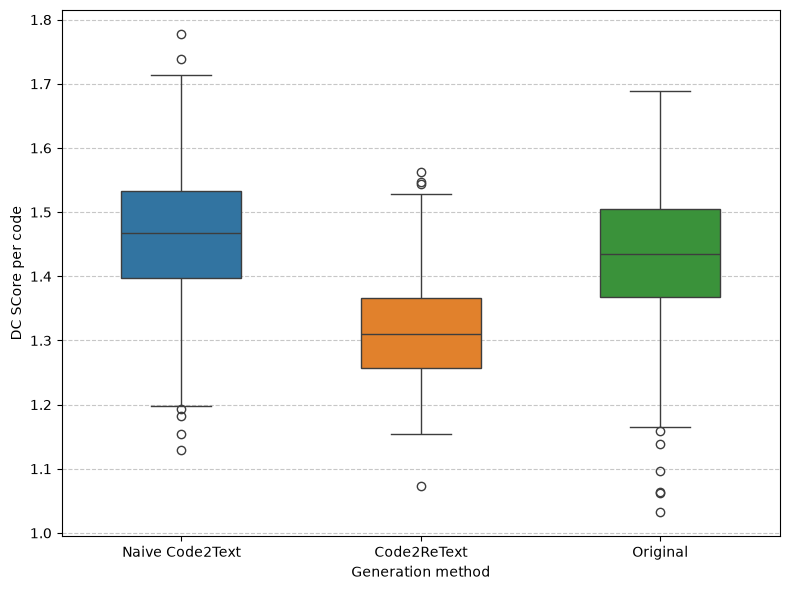

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].rename(
    columns={
        "dcscore_A": "Naive Code2Text",
        "dcscore_B": "Code2ReText",
        "dcscore_C": "Original"
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("DC SCore per code", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

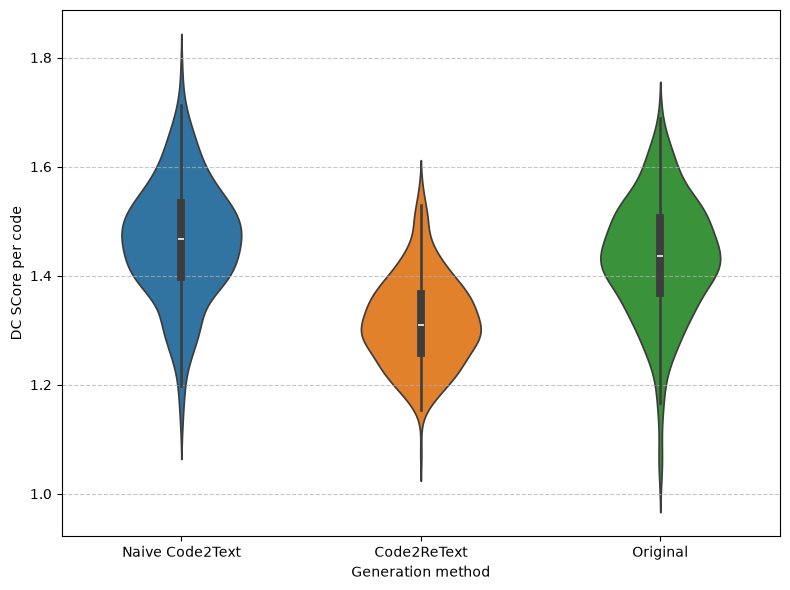

In [88]:
df_plot = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].rename(
    columns={
        "dcscore_A": "Naive Code2Text",
        "dcscore_B": "Code2ReText",
        "dcscore_C": "Original"
    }
)

plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("DC SCore per code", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [89]:
from scipy import stats

# 1. Nettoyage global : on supprime les lignes où un score est manquant (NaN) ou nul (0.0)
df_clean = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].dropna()
df_clean = df_clean[(df_clean != 0).all(axis=1)]

# Extraction des séries appariées
group_A = df_clean["dcscore_A"]  # Naive Code2Text
group_B = df_clean["dcscore_B"]  # Code2ReText
group_C = df_clean["dcscore_C"]  # Original

# 2. Exécution des tests de Wilcoxon (données appariées)
stat_AC, p_AC = stats.wilcoxon(group_A, group_C)
stat_BC, p_BC = stats.wilcoxon(group_B, group_C)
stat_AB, p_AB = stats.wilcoxon(group_A, group_B)

# 3. Correction de Bonferroni pour 3 comparaisons simultanées
alpha_initial = 0.05
nb_comparisons = 3
alpha_corrected = alpha_initial / nb_comparisons

print("--- Résultats des Tests de Wilcoxon (Données Appariées) ---")
print(f"Seuil de significativité corrigé (Bonferroni) : alpha = {alpha_corrected:.4f}\n")

def interpret_comparison(name_1, group_1, name_2, group_2, p_val):
    med_1, med_2 = group_1.median(), group_2.median()
    print(f"[{name_1} vs {name_2}]")
    print(f"  p-value : {p_val:.5e}")
    print(f"  Médianes : {name_1} = {med_1:.4f} | {name_2} = {med_2:.4f}")
    
    if p_val < alpha_corrected:
        print(f"  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).")
        if med_1 > med_2:
            print(f"  -> {name_1} montre une diversité (DCScore) significativement plus élevée que {name_2}.\n")
        else:
            print(f"  -> {name_2} montre une diversité (DCScore) significativement plus élevée que {name_1}.\n")
    else:
        print(f"  -> Pas de différence statistiquement significative (p >= alpha).\n")

# Affichage des interprétations
interpret_comparison("Naive Code2Text (A)", group_A, "Original (C)", group_C, p_AC)
interpret_comparison("Code2ReText (B)", group_B, "Original (C)", group_C, p_BC)
interpret_comparison("Naive Code2Text (A)", group_A, "Code2ReText (B)", group_B, p_AB)

--- Résultats des Tests de Wilcoxon (Données Appariées) ---
Seuil de significativité corrigé (Bonferroni) : alpha = 0.0167

[Naive Code2Text (A) vs Original (C)]
  p-value : 1.97486e-11
  Médianes : Naive Code2Text (A) = 1.4678 | Original (C) = 1.4353
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Naive Code2Text (A) montre une diversité (DCScore) significativement plus élevée que Original (C).

[Code2ReText (B) vs Original (C)]
  p-value : 3.07138e-51
  Médianes : Code2ReText (B) = 1.3104 | Original (C) = 1.4353
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Original (C) montre une diversité (DCScore) significativement plus élevée que Code2ReText (B).

[Naive Code2Text (A) vs Code2ReText (B)]
  p-value : 2.68417e-60
  Médianes : Naive Code2Text (A) = 1.4678 | Code2ReText (B) = 1.3104
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Naive Code2Text (A) montre une diversité (DCScore) significativement plus élevée que Code2ReText (B).



In [91]:
import pingouin as pg
import numpy as np

# 1. Nettoyage et alignement global des données
# On s'assure d'avoir les trois scores pour un même code pour que les comparaisons restent équitables
df_clean = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].dropna()
df_clean = df_clean[(df_clean != 0).all(axis=1)]

# 2. Calcul des t-tests bayésiens appariés par rapport à l'Original (C)
res_AC = pg.ttest(df_clean["dcscore_A"], df_clean["dcscore_C"], paired=True)
res_BC = pg.ttest(df_clean["dcscore_B"], df_clean["dcscore_C"], paired=True)

# Extraction des indicateurs
bf10_AC = res_AC['BF10'].astype(float).values[0]
d_cohen_AC = res_AC['cohen_d'].values[0]

bf10_BC = res_BC['BF10'].astype(float).values[0]
d_cohen_BC = res_BC['cohen_d'].values[0]

# Médianes pour l'analyse de la direction
median_A = df_clean["dcscore_A"].median()
median_B = df_clean["dcscore_B"].median()
median_C = df_clean["dcscore_C"].median()

print("--- RÉSULTATS DES T-TESTS BAYÉSIENS APPARIÉS (vs ORIGINAL C) ---")
print(f"Médianes de diversité : Naive (A) = {median_A:.4f} | ReText (B) = {median_B:.4f} | Original (C) = {median_C:.4f}\n")

def print_bayesian_interpretation(pair_name, bf10, d_cohen, med_method, med_original, method_label):
    print(f"=== Comparaison {pair_name} ===")
    print(f"  Facteur de Bayes (BF10) : {bf10:.4e}")
    print(f"  Taille de l'effet (d de Cohen) : {d_cohen:.4f}")
    
    # Échelle de Jeffreys
    if bf10 > 100:
        evidence = "Preuve extrême en faveur d'une différence de diversité."
    elif bf10 > 10:
        evidence = "Preuve forte en faveur d'une différence de diversité."
    elif bf10 > 3:
        evidence = "Preuve modérée en faveur d'une différence de diversité."
    elif 1/3 <= bf10 <= 3:
        evidence = "Données anecdotiques : niveau de diversité équivalent à l'original."
    elif bf10 < 1/10:
        evidence = "Preuve forte en faveur de l'hypothèse nulle (diversité strictement identique à l'original)."
    else:
        evidence = "Preuve modérée en faveur de l'hypothèse nulle."
        
    print(f"  Analyse : {evidence}")
    
    # Direction de l'effet
    if bf10 > 3:
        if med_method > med_original:
            print(f"  Conclusion : La méthode {method_label} sur-génère de la diversité par rapport à l'Original.")
        else:
            print(f"  Conclusion : La méthode {method_label} sous-génère de la diversité (plus monotone) par rapport à l'Original.")
    else:
        print(f"  Conclusion : La méthode {method_label} reproduit fidèlement le niveau de diversité de l'Original.")
    print("\n")

# Affichage des résultats pour chaque méthode face à la référence
print_bayesian_interpretation("Naive (A) vs Original (C)", bf10_AC, d_cohen_AC, median_A, median_C, "Naive Code2Text")
print_bayesian_interpretation("ReText (B) vs Original (C)", bf10_BC, d_cohen_BC, median_B, median_C, "Code2ReText")

--- RÉSULTATS DES T-TESTS BAYÉSIENS APPARIÉS (vs ORIGINAL C) ---
Médianes de diversité : Naive (A) = 1.4678 | ReText (B) = 1.3104 | Original (C) = 1.4353

=== Comparaison Naive (A) vs Original (C) ===
  Facteur de Bayes (BF10) : 7.4680e+08
  Taille de l'effet (d de Cohen) : 0.3025
  Analyse : Preuve extrême en faveur d'une différence de diversité.
  Conclusion : La méthode Naive Code2Text sur-génère de la diversité par rapport à l'Original.


=== Comparaison ReText (B) vs Original (C) ===
  Facteur de Bayes (BF10) : 8.5190e+70
  Taille de l'effet (d de Cohen) : 1.1992
  Analyse : Preuve extrême en faveur d'une différence de diversité.
  Conclusion : La méthode Code2ReText sous-génère de la diversité (plus monotone) par rapport à l'Original.




## Wasserstein distance test

In [71]:
DATASET_METRICS_PATH = "s3://mateom/graal/compare_datasets_test.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "test_prod"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)

df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 55.90Y to 96.21G
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   count_A                  270 non-null    int64  
 1   count_B                  270 non-null    int64  
 2   count_C                  270 non-null    int64  
 3   wasserstein_distance_AC  270 non-null    float64
 4   wasserstein_distance_BC  270 non-null    float64
 5   wasserstein_distance_AB  270 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 14.8+ KB


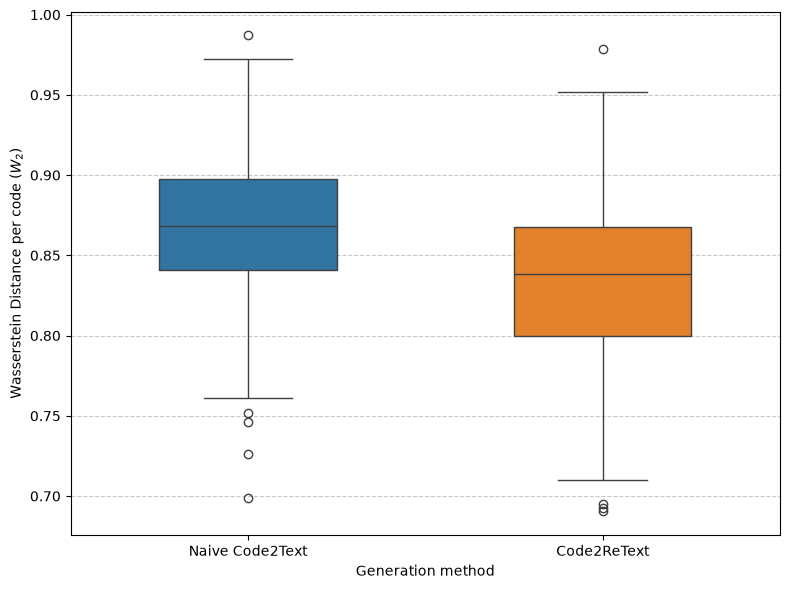

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].rename(
    columns={
        "wasserstein_distance_AC": "Naive Code2Text",
        "wasserstein_distance_BC": "Code2ReText",
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

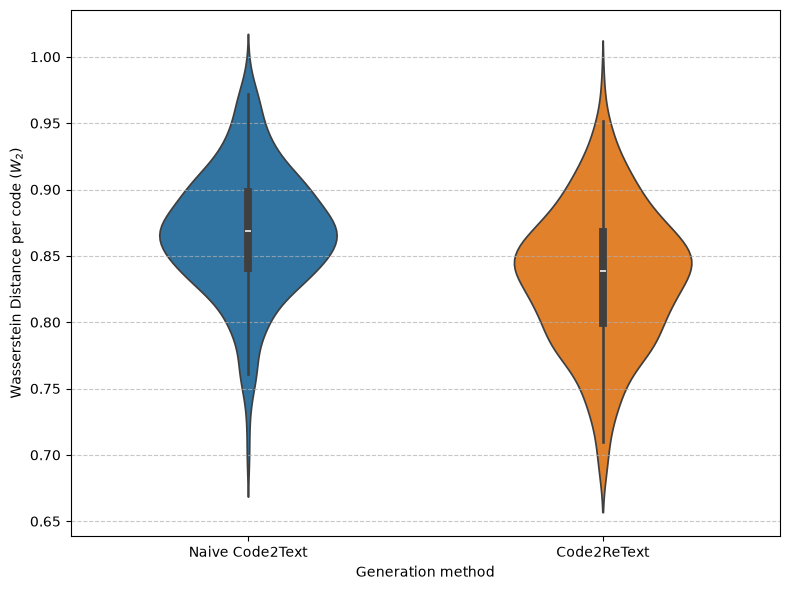

In [73]:
plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [74]:
# Extraction des séries en enlevant les potentielles valeurs manquantes (NaN)
# dues aux codes absents de certaines collections
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du test de Wilcoxon pour données appariées
stat, p_value = stats.wilcoxon(group_A, group_B)

print("--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---")
print(f"Statistique de test : {stat:.2f}")
print(f"p-value : {p_value:.5e}")

# Interprétation bayésienne/fréquentiste standard (seuil alpha à 5%)
alpha = 0.05
if p_value < alpha:
    print("\nConclusion : La différence est statistiquement significative (p < 0.05).")
    median_A = group_A.median()
    median_B = group_B.median()
    if median_B < median_A:
        print(f"Code2ReText (Médiane: {median_B:.4f}) est significativement plus proche de l'original C que Naive Code2Text (Médiane: {median_A:.4f}).")
    else:
        print(f"Naive Code2Text (Médiane: {median_A:.4f}) est significativement plus proche.")
else:
    print("\nConclusion : Pas de différence statistiquement significative détectée (p >= 0.05). Les deux méthodes ont des distributions de distances similaires.")

--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---
Statistique de test : 3093.00
p-value : 2.57218e-32

Conclusion : La différence est statistiquement significative (p < 0.05).
Code2ReText (Médiane: 0.8384) est significativement plus proche de l'original C que Naive Code2Text (Médiane: 0.8684).


In [75]:
from scipy import stats

# Nettoyage des données pour aligner parfaitement les codes
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du t-test apparié
t_stat, p_value = stats.ttest_rel(group_A, group_B)

print("--- Résultats du T-Test Apparié (Paired T-Test) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_value:.5e}")

alpha = 0.05
if p_value < alpha:
    mean_A = group_A.mean()
    mean_B = group_B.mean()
    print(f"\nConclusion : Différence statistiquement significative (p < 0.05).")
    if mean_B < mean_A:
        print(f"Code2ReText (Moyenne: {mean_B:.4f}) surpasse Naive Code2Text (Moyenne: {mean_A:.4f}) en se rapprochant de l'original.")
    else:
        print(f"Naive Code2Text (Moyenne: {mean_A:.4f}) est statistiquement plus proche.")
else:
    print("\nConclusion : Aucune différence statistiquement significative constatée.")

--- Résultats du T-Test Apparié (Paired T-Test) ---
Statistique t : 14.6033
p-value : 5.79008e-36

Conclusion : Différence statistiquement significative (p < 0.05).
Code2ReText (Moyenne: 0.8338) surpasse Naive Code2Text (Moyenne: 0.8673) en se rapprochant de l'original.


In [76]:
import pingouin as pg

# Nettoyage et alignement des données
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

# Calcul du t-test bayésien apparié
# 'paired=True' active la comparaison intra-code
res = pg.ttest(
    df_clean["wasserstein_distance_AC"], 
    df_clean["wasserstein_distance_BC"], 
    paired=True
)

# Extraction des indicateurs clés
bf10 = res['BF10'].astype(float).values[0]
d_cohen = res['cohen_d'].values[0]
p_val = res['p_val'].values[0]  # Fourni aussi par pingouin pour comparaison

print("--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---")
print(f"Facteur de Bayes (BF10) : {bf10:.4e}")
print(f"Taille de l'effet (d de Cohen) : {d_cohen:.4f}")

print("\n--- INTERPRÉTATION BAYÉSIENNE ---")
# Échelle d'interprétation de Jeffreys pour le Facteur de Bayes
if bf10 > 100:
    print("Preuve extrême en faveur d'une différence entre les deux méthodes.")
elif bf10 > 30:
    print("Preuve très forte en faveur d'une différence.")
elif bf10 > 10:
    print("Preuve forte en faveur d'une différence.")
elif bf10 > 3:
    print("Preuve modérée en faveur d'une différence.")
elif 1/3 <= bf10 <= 3:
    print("Les données sont anecdotiques, impossible de trancher (les deux modèles se valent).")
elif bf10 < 1/10:
    print("Preuve forte en faveur de l'hypothèse nulle (les méthodes sont strictement équivalentes).")
else:
    print("Preuve modérée/extrême en faveur de l'hypothèse nulle.")

# Analyse directionnelle
mean_AC = df_clean["wasserstein_distance_AC"].mean()
mean_BC = df_clean["wasserstein_distance_BC"].mean()
print(f"\nDistance moyenne AC (Naïve) : {mean_AC:.4f}")
print(f"Distance moyenne BC (ReText) : {mean_BC:.4f}")

if bf10 > 3:
    if mean_BC < mean_AC:
        print("Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.")
    else:
        print("Conclusion : La méthode Naïve reste plus proche de l'original.")

--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---
Facteur de Bayes (BF10) : 4.4990e+32
Taille de l'effet (d de Cohen) : 0.6842

--- INTERPRÉTATION BAYÉSIENNE ---
Preuve extrême en faveur d'une différence entre les deux méthodes.

Distance moyenne AC (Naïve) : 0.8673
Distance moyenne BC (ReText) : 0.8338
Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.


## DCScore Test

In [92]:
DATASET_METRICS_PATH = "s3://mateom/graal/dcscore_test.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "original_cleaned"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)
df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 55.90Y to 96.21G
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   count_A    270 non-null    int64  
 1   dcscore_A  270 non-null    float64
 2   count_B    270 non-null    int64  
 3   dcscore_B  270 non-null    float64
 4   count_C    270 non-null    int64  
 5   dcscore_C  270 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 14.8+ KB


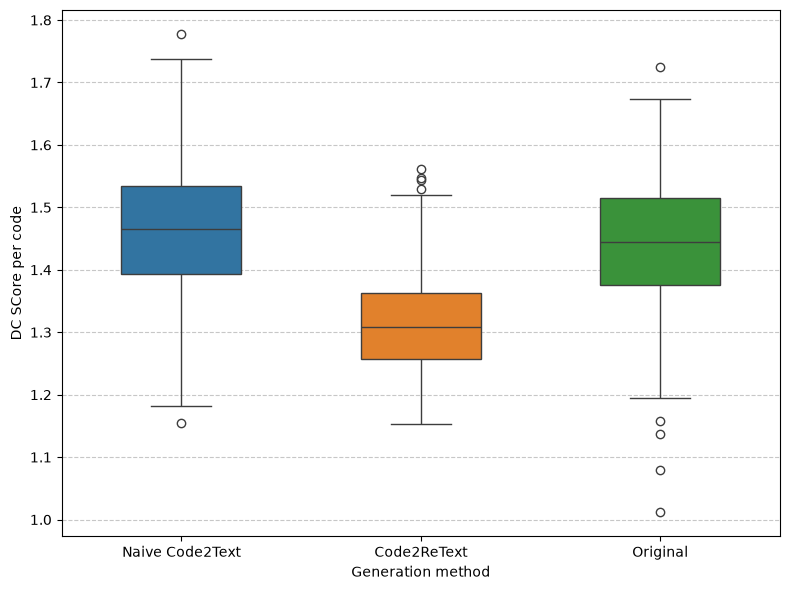

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].rename(
    columns={
        "dcscore_A": "Naive Code2Text",
        "dcscore_B": "Code2ReText",
        "dcscore_C": "Original"
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("DC SCore per code", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

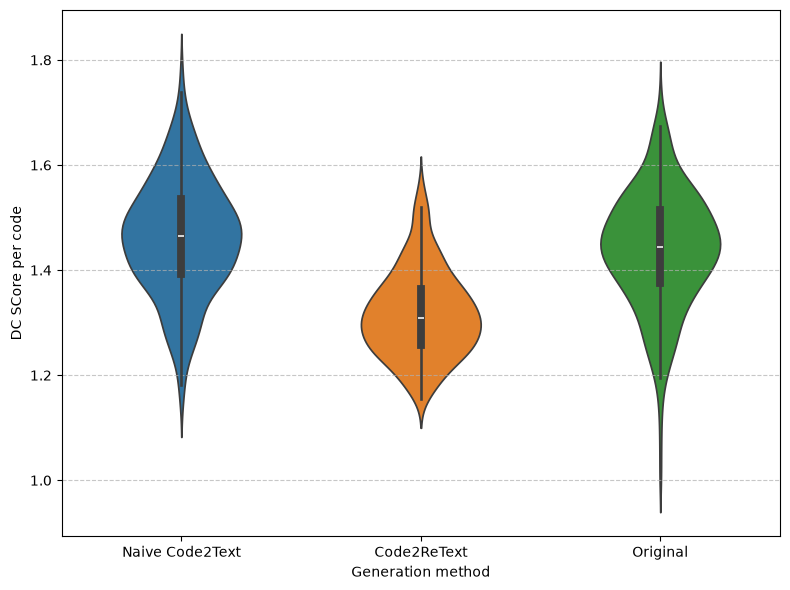

In [94]:
df_plot = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].rename(
    columns={
        "dcscore_A": "Naive Code2Text",
        "dcscore_B": "Code2ReText",
        "dcscore_C": "Original"
    }
)

plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("DC SCore per code", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [95]:
from scipy import stats

# 1. Nettoyage global : on supprime les lignes où un score est manquant (NaN) ou nul (0.0)
df_clean = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].dropna()
df_clean = df_clean[(df_clean != 0).all(axis=1)]

# Extraction des séries appariées
group_A = df_clean["dcscore_A"]  # Naive Code2Text
group_B = df_clean["dcscore_B"]  # Code2ReText
group_C = df_clean["dcscore_C"]  # Original

# 2. Exécution des tests de Wilcoxon (données appariées)
stat_AC, p_AC = stats.wilcoxon(group_A, group_C)
stat_BC, p_BC = stats.wilcoxon(group_B, group_C)
stat_AB, p_AB = stats.wilcoxon(group_A, group_B)

# 3. Correction de Bonferroni pour 3 comparaisons simultanées
alpha_initial = 0.05
nb_comparisons = 3
alpha_corrected = alpha_initial / nb_comparisons

print("--- Résultats des Tests de Wilcoxon (Données Appariées) ---")
print(f"Seuil de significativité corrigé (Bonferroni) : alpha = {alpha_corrected:.4f}\n")

def interpret_comparison(name_1, group_1, name_2, group_2, p_val):
    med_1, med_2 = group_1.median(), group_2.median()
    print(f"[{name_1} vs {name_2}]")
    print(f"  p-value : {p_val:.5e}")
    print(f"  Médianes : {name_1} = {med_1:.4f} | {name_2} = {med_2:.4f}")
    
    if p_val < alpha_corrected:
        print(f"  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).")
        if med_1 > med_2:
            print(f"  -> {name_1} montre une diversité (DCScore) significativement plus élevée que {name_2}.\n")
        else:
            print(f"  -> {name_2} montre une diversité (DCScore) significativement plus élevée que {name_1}.\n")
    else:
        print(f"  -> Pas de différence statistiquement significative (p >= alpha).\n")

# Affichage des interprétations
interpret_comparison("Naive Code2Text (A)", group_A, "Original (C)", group_C, p_AC)
interpret_comparison("Code2ReText (B)", group_B, "Original (C)", group_C, p_BC)
interpret_comparison("Naive Code2Text (A)", group_A, "Code2ReText (B)", group_B, p_AB)

--- Résultats des Tests de Wilcoxon (Données Appariées) ---
Seuil de significativité corrigé (Bonferroni) : alpha = 0.0167

[Naive Code2Text (A) vs Original (C)]
  p-value : 1.04076e-03
  Médianes : Naive Code2Text (A) = 1.4646 | Original (C) = 1.4446
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Naive Code2Text (A) montre une diversité (DCScore) significativement plus élevée que Original (C).

[Code2ReText (B) vs Original (C)]
  p-value : 5.81733e-35
  Médianes : Code2ReText (B) = 1.3083 | Original (C) = 1.4446
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Original (C) montre une diversité (DCScore) significativement plus élevée que Code2ReText (B).

[Naive Code2Text (A) vs Code2ReText (B)]
  p-value : 6.47237e-44
  Médianes : Naive Code2Text (A) = 1.4646 | Code2ReText (B) = 1.3083
  -> Différence STATISTIQUEMENT SIGNIFICATIVE (p < alpha).
  -> Naive Code2Text (A) montre une diversité (DCScore) significativement plus élevée que Code2ReText (B).



In [96]:
import pingouin as pg
import numpy as np

# 1. Nettoyage et alignement global des données
# On s'assure d'avoir les trois scores pour un même code pour que les comparaisons restent équitables
df_clean = df_metrics[["dcscore_A", "dcscore_B", "dcscore_C"]].dropna()
df_clean = df_clean[(df_clean != 0).all(axis=1)]

# 2. Calcul des t-tests bayésiens appariés par rapport à l'Original (C)
res_AC = pg.ttest(df_clean["dcscore_A"], df_clean["dcscore_C"], paired=True)
res_BC = pg.ttest(df_clean["dcscore_B"], df_clean["dcscore_C"], paired=True)

# Extraction des indicateurs
bf10_AC = res_AC['BF10'].astype(float).values[0]
d_cohen_AC = res_AC['cohen_d'].values[0]

bf10_BC = res_BC['BF10'].astype(float).values[0]
d_cohen_BC = res_BC['cohen_d'].values[0]

# Médianes pour l'analyse de la direction
median_A = df_clean["dcscore_A"].median()
median_B = df_clean["dcscore_B"].median()
median_C = df_clean["dcscore_C"].median()

print("--- RÉSULTATS DES T-TESTS BAYÉSIENS APPARIÉS (vs ORIGINAL C) ---")
print(f"Médianes de diversité : Naive (A) = {median_A:.4f} | ReText (B) = {median_B:.4f} | Original (C) = {median_C:.4f}\n")

def print_bayesian_interpretation(pair_name, bf10, d_cohen, med_method, med_original, method_label):
    print(f"=== Comparaison {pair_name} ===")
    print(f"  Facteur de Bayes (BF10) : {bf10:.4e}")
    print(f"  Taille de l'effet (d de Cohen) : {d_cohen:.4f}")
    
    # Échelle de Jeffreys
    if bf10 > 100:
        evidence = "Preuve extrême en faveur d'une différence de diversité."
    elif bf10 > 10:
        evidence = "Preuve forte en faveur d'une différence de diversité."
    elif bf10 > 3:
        evidence = "Preuve modérée en faveur d'une différence de diversité."
    elif 1/3 <= bf10 <= 3:
        evidence = "Données anecdotiques : niveau de diversité équivalent à l'original."
    elif bf10 < 1/10:
        evidence = "Preuve forte en faveur de l'hypothèse nulle (diversité strictement identique à l'original)."
    else:
        evidence = "Preuve modérée en faveur de l'hypothèse nulle."
        
    print(f"  Analyse : {evidence}")
    
    # Direction de l'effet
    if bf10 > 3:
        if med_method > med_original:
            print(f"  Conclusion : La méthode {method_label} sur-génère de la diversité par rapport à l'Original.")
        else:
            print(f"  Conclusion : La méthode {method_label} sous-génère de la diversité (plus monotone) par rapport à l'Original.")
    else:
        print(f"  Conclusion : La méthode {method_label} reproduit fidèlement le niveau de diversité de l'Original.")
    print("\n")

# Affichage des résultats pour chaque méthode face à la référence
print_bayesian_interpretation("Naive (A) vs Original (C)", bf10_AC, d_cohen_AC, median_A, median_C, "Naive Code2Text")
print_bayesian_interpretation("ReText (B) vs Original (C)", bf10_BC, d_cohen_BC, median_B, median_C, "Code2ReText")

--- RÉSULTATS DES T-TESTS BAYÉSIENS APPARIÉS (vs ORIGINAL C) ---
Médianes de diversité : Naive (A) = 1.4646 | ReText (B) = 1.3083 | Original (C) = 1.4446

=== Comparaison Naive (A) vs Original (C) ===
  Facteur de Bayes (BF10) : 8.3619e+01
  Taille de l'effet (d de Cohen) : 0.2137
  Analyse : Preuve forte en faveur d'une différence de diversité.
  Conclusion : La méthode Naive Code2Text sur-génère de la diversité par rapport à l'Original.


=== Comparaison ReText (B) vs Original (C) ===
  Facteur de Bayes (BF10) : 9.0840e+47
  Taille de l'effet (d de Cohen) : 1.2400
  Analyse : Preuve extrême en faveur d'une différence de diversité.
  Conclusion : La méthode Code2ReText sous-génère de la diversité (plus monotone) par rapport à l'Original.


